# Chapter 1 — Exploratory Data Analysis

## Learning Objectives

By the end of this notebook, you should be able to explain the role of exploratory data analysis, distinguish numeric and categorical data, compute robust estimates of location and variability, visualize distributions, inspect correlation, and compare variables using appropriate plots.

## Theoretical Explanation

Exploratory Data Analysis (EDA) is the first practical step in a data science project. Before building models, the analyst should understand the structure, quality, distribution, and relationships in the data. EDA combines summary statistics and visual tools. Measures of location such as mean, median, trimmed mean, and weighted mean describe typical values. Measures of variability such as standard deviation, interquartile range, and median absolute deviation describe spread.

A key lesson is robustness. The mean and standard deviation are sensitive to outliers, while the median, trimmed mean, IQR, and MAD are more resistant. Visualization is equally important because a single number cannot reveal skewness, multimodality, outliers, or nonlinear relationships. Histograms, density plots, boxplots, scatterplots, and correlation matrices each answer different exploratory questions.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Location and Variability Estimates

This example creates a synthetic income-like distribution with outliers to compare ordinary and robust summaries.

In [2]:
rng = np.random.RandomState(RANDOM_STATE)
income = rng.lognormal(mean=10.5, sigma=0.55, size=500)
income = np.r_[income, [500000, 750000, 900000]]

summary = {
    'mean': np.mean(income),
    'median': np.median(income),
    'trimmed_mean_10pct': stats.trim_mean(income, 0.10),
    'std': np.std(income, ddof=1),
    'IQR': np.percentile(income, 75) - np.percentile(income, 25),
    'MAD': stats.median_abs_deviation(income, scale='normal')
}
print(pd.Series(summary).round(2))

mean                  46421.72
median                36737.46
trimmed_mean_10pct    38667.30
std                   59871.33
IQR                   27147.95
MAD                   19465.27
dtype: float64


### Output Interpretation

The mean and standard deviation are pulled upward by extreme income values. The median, trimmed mean, IQR, and MAD are more robust and better describe the typical range when outliers exist.

## 2. Distribution Visualization

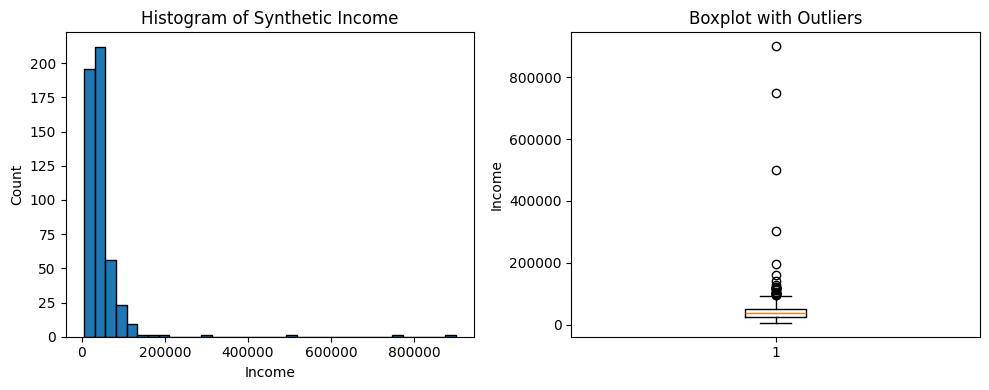

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(income, bins=35, edgecolor='black')
ax[0].set_title('Histogram of Synthetic Income')
ax[0].set_xlabel('Income')
ax[0].set_ylabel('Count')
ax[1].boxplot(income, vert=True)
ax[1].set_title('Boxplot with Outliers')
ax[1].set_ylabel('Income')
plt.tight_layout()
plt.show()

### Output Interpretation

The histogram shows right skewness and the boxplot highlights extreme high values. These visualizations make the outlier problem obvious in a way that a mean alone cannot.

## 3. Correlation and Scatterplots

Correlation matrix:
       x      y      z
x  1.000  0.719 -0.024
y  0.719  1.000 -0.073
z -0.024 -0.073  1.000


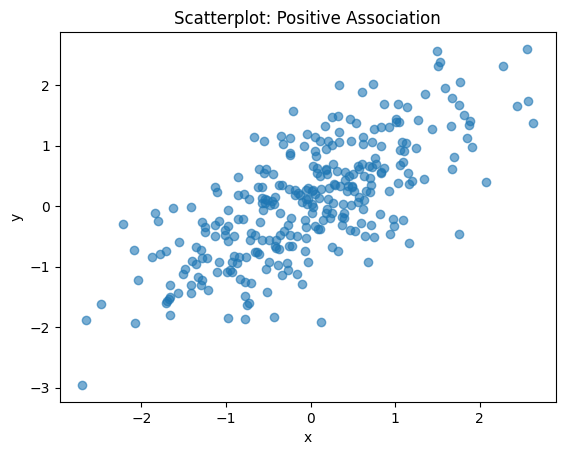

In [4]:
x = rng.normal(size=300)
y = 0.7*x + rng.normal(scale=0.7, size=300)
z = rng.normal(size=300)
df = pd.DataFrame({'x': x, 'y': y, 'z': z})
print('Correlation matrix:')
print(df.corr().round(3))

plt.scatter(df['x'], df['y'], alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatterplot: Positive Association')
plt.show()

### Output Interpretation

The correlation matrix shows that `x` and `y` have a positive linear relationship, while `z` is mostly unrelated. The scatterplot confirms the positive association visually.

## 4. Categorical and Numeric Comparison

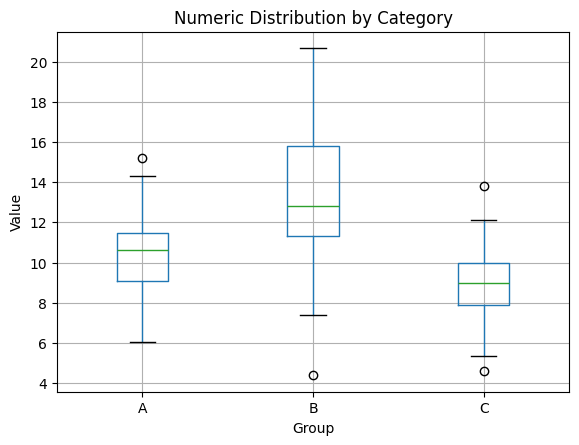

        mean  median   std
group                     
A      10.42   10.62  1.87
B      13.35   12.83  3.28
C       8.92    8.96  1.59


In [5]:
groups = pd.DataFrame({
    'group': np.repeat(['A', 'B', 'C'], 80),
    'value': np.r_[rng.normal(10, 2, 80), rng.normal(13, 3, 80), rng.normal(9, 1.5, 80)]
})
groups.boxplot(column='value', by='group')
plt.title('Numeric Distribution by Category')
plt.suptitle('')
plt.xlabel('Group')
plt.ylabel('Value')
plt.show()
print(groups.groupby('group')['value'].agg(['mean', 'median', 'std']).round(2))

### Output Interpretation

The grouped boxplot compares distribution shape, center, and spread across categories. Group B has a higher center and greater variability than the other groups.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.